## Cell 1: Libraries & Data Loading

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("customer_shopping_data.csv")

print("--- DATA QUALITY CHECK ---")
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)
df.head(3)

--- DATA QUALITY CHECK ---
Shape: (99457, 10)

Missing Values:
 invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

Data Types:
 invoice_no         object
customer_id        object
gender             object
age                 int64
category           object
quantity            int64
price             float64
payment_method     object
invoice_date       object
shopping_mall      object
dtype: object


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity


## Cell 2: Data Cleaning, Date Formatting & Feature Engineering

In [4]:
# Convert invoice_date to datetime format (%d/%m/%Y)
df['invoice_date'] = pd.to_datetime(df['invoice_date'], format='%d/%m/%Y')

# Extract year and month features for temporal analysis
df['year'] = df['invoice_date'].dt.year
df['month'] = df['invoice_date'].dt.month

# Calculate total revenue per transaction (quantity * unit price)
df['total_revenue'] = df['quantity'] * df['price']

print("Date conversion and feature extraction completed successfully!")
df[['invoice_date', 'year', 'month', 'total_revenue']].head(3)

Date conversion and feature extraction completed successfully!


,invoice_date,year,month,total_revenue
0,2022-08-05,2022,8,7502.00
1,2021-12-12,2021,12,5401.53
2,2021-11-09,2021,11,300.08


## Cell 3: Multi-Dimensional Aggregations & Pivot Tables

In [5]:
# 1. Revenue & Average Purchase by Category
category_summary = df.groupby('category').agg(
    Total_Revenue=('price', 'sum'),
    Avg_Purchase=('price', 'mean'),
    Transaction_Count=('invoice_no', 'count')
).sort_values(by='Total_Revenue', ascending=False)

print("--- REVENUE RANKING BY CATEGORY ---")
print(category_summary)

# 2. Pivot Table: Shopping Mall vs Category (Total Revenue)
mall_category_pivot = df.pivot_table(
    index='shopping_mall', 
    columns='category', 
    values='price', 
    aggfunc='sum', 
    fill_value=0
)

print("\n--- PIVOT TABLE: MALL VS CATEGORY (REVENUE) ---")
print(mall_category_pivot)

# 3. Bonus: Payment Method Dominance by Category
payment_dominance = df.groupby(['category', 'payment_method'])['price'].sum().unstack()
print("\n--- PAYMENT METHOD DISTRIBUTION BY CATEGORY ---")
print(payment_dominance)

--- REVENUE RANKING BY CATEGORY ---
                 Total_Revenue  Avg_Purchase  Transaction_Count
category                                                       
Clothing           31075684.64    901.084021              34487
Shoes              18135336.89   1807.388568              10034
Technology         15772050.00   3156.935548               4996
Cosmetics           1848606.90    122.448626              15097
Toys                1086704.64    107.733185              10087
Food & Beverage      231568.71     15.671948              14776
Books                226977.30     45.568621               4981
Souvenir             174436.83     34.894345               4999

--- PIVOT TABLE: MALL VS CATEGORY (REVENUE) ---
category              Books    Clothing  Cosmetics  Food & Beverage  \
shopping_mall                                                         
Cevahir AVM        11998.80  1554414.40   88394.84         11992.39   
Emaar Square Mall  11059.50  1511803.04   92379.52         110

## Cell 4: Visualizations & Analytics (Heatmap, Line Chart, Grouped Bar Chart)

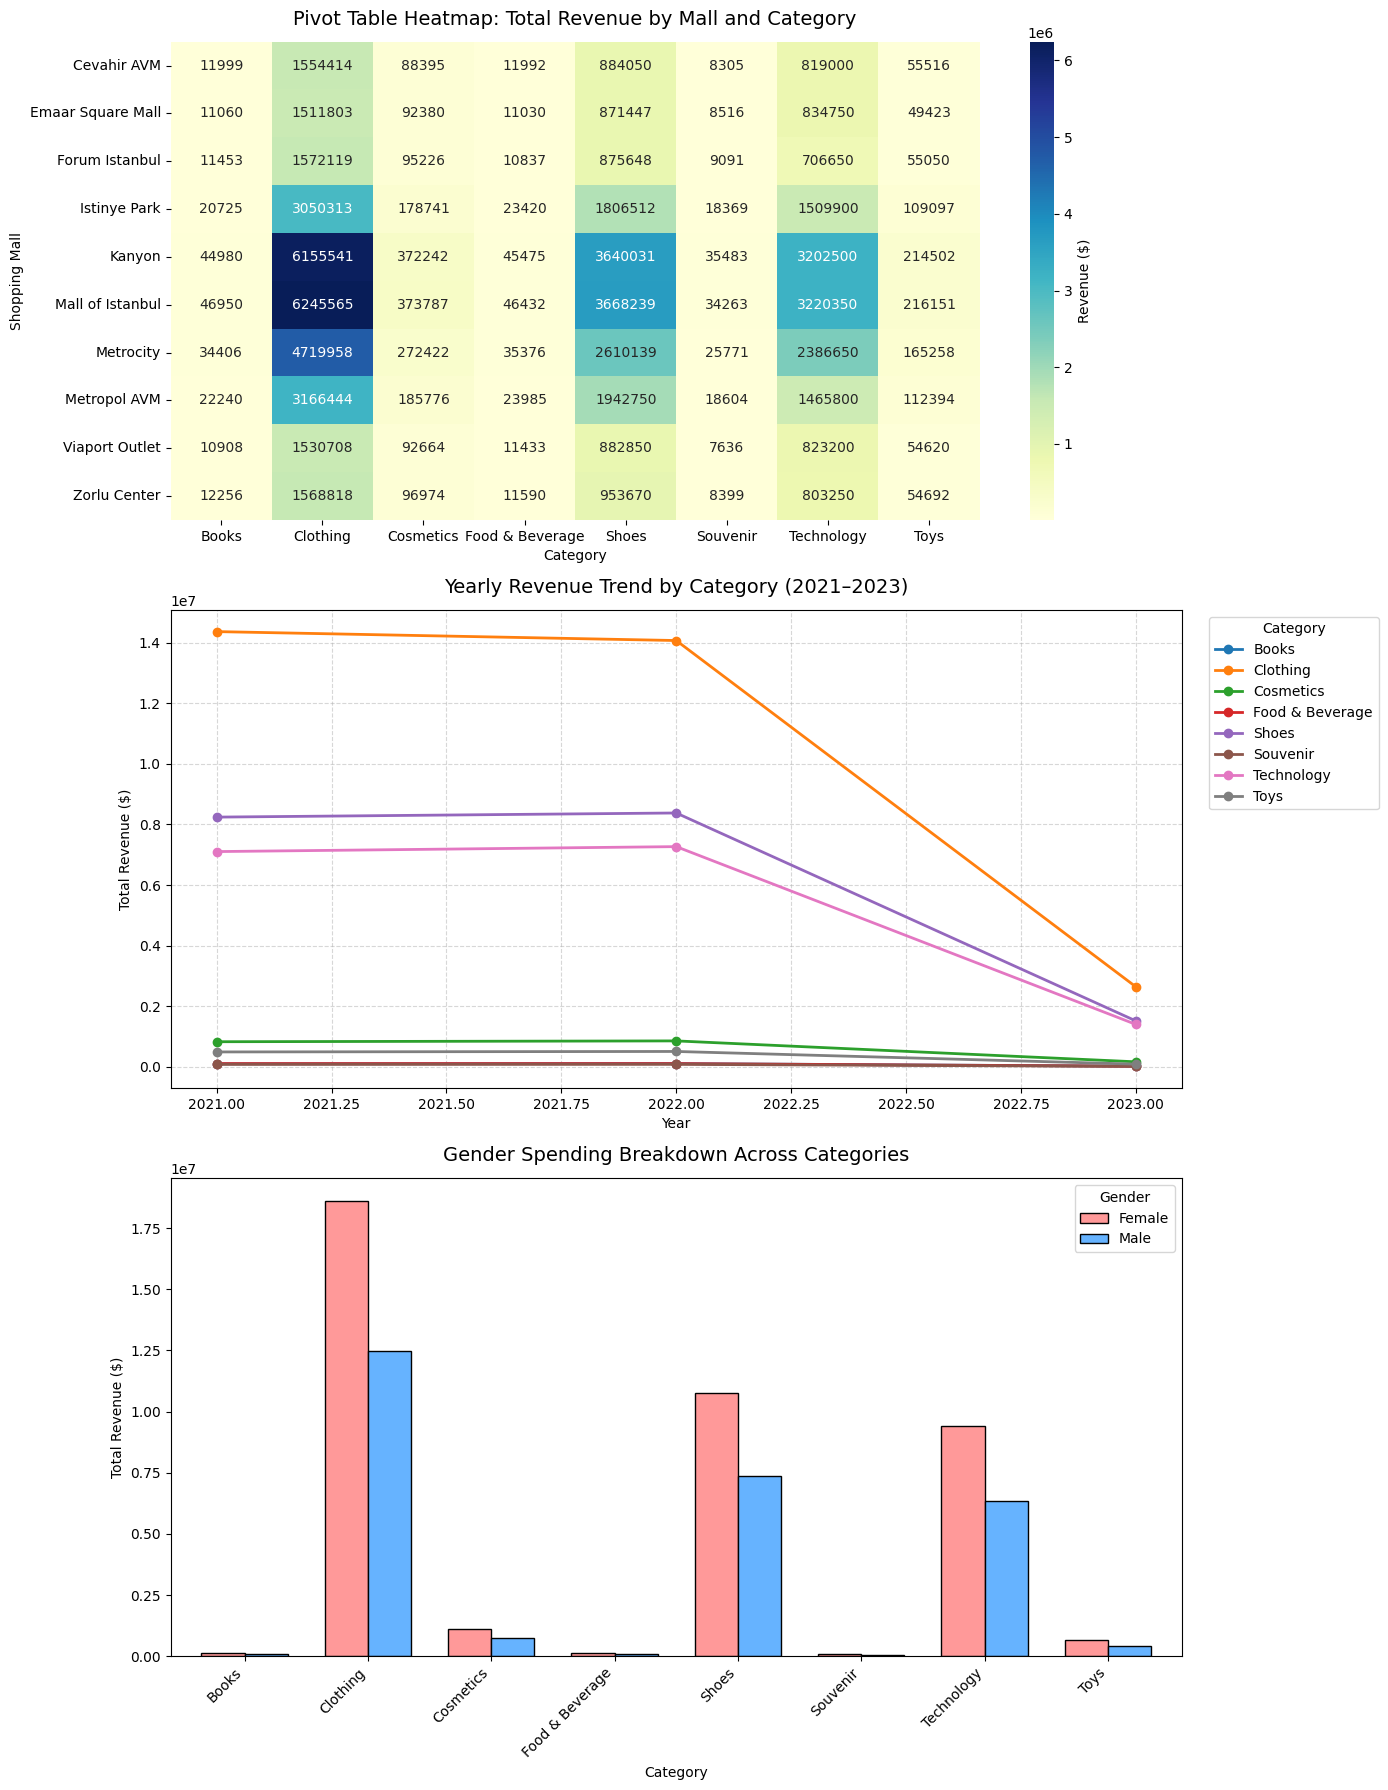

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# 1. Heatmap: Shopping Mall vs Category Revenue
sns.heatmap(mall_category_pivot, annot=True, fmt=".0f", cmap="YlGnBu", ax=axes[0], cbar_kws={'label': 'Revenue ($)'})
axes[0].set_title('Pivot Table Heatmap: Total Revenue by Mall and Category', fontsize=14, pad=12)
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Shopping Mall')

# 2. Line Chart: Yearly Revenue Trend per Category (2021–2023)
yearly_category = df.groupby(['year', 'category'])['price'].sum().unstack()
yearly_category.plot(kind='line', marker='o', linewidth=2, ax=axes[1])
axes[1].set_title('Yearly Revenue Trend by Category (2021–2023)', fontsize=14, pad=12)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Revenue ($)')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')

# 3. Grouped Bar Chart: Gender vs Spending by Category
gender_category = df.groupby(['category', 'gender'])['price'].sum().unstack()
gender_category.plot(kind='bar', ax=axes[2], color=['#ff9999', '#66b3ff'], edgecolor='black', width=0.7)
axes[2].set_title('Gender Spending Breakdown Across Categories', fontsize=14, pad=12)
axes[2].set_xlabel('Category')
axes[2].set_ylabel('Total Revenue ($)')
axes[2].set_xticklabels(gender_category.index, rotation=45, ha='right')
axes[2].legend(title='Gender')

plt.tight_layout()
plt.show()